In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.dpi'] = 100

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. 数据加载

In [42]:
# 加载数据
train_path = '../DataSplit/TrainTest/Train.csv'
test_path = '../DataSplit/TrainTest/Test.csv'

df_train = pd.read_csv(train_path, parse_dates=['time'])
df_test = pd.read_csv(test_path, parse_dates=['time'])

print(f"训练集: {df_train.shape[0]} 条记录, {df_train['id'].nunique()} 个受试者")
print(f"测试集: {df_test.shape[0]} 条记录, {df_test['id'].nunique()} 个受试者")
df_train.head()

训练集: 83253 条记录, 158 个受试者
测试集: 11376 条记录, 158 个受试者


,id,time,gl,age,bmi
0,3,2012-01-01 00:00:00,89.539216,61.0,33.8
1,3,2012-01-01 00:05:00,90.070728,61.0,33.8
2,3,2012-01-01 00:10:00,90.366300,61.0,33.8
3,3,2012-01-01 00:15:00,90.450442,61.0,33.8
4,3,2012-01-01 00:20:00,90.347662,61.0,33.8


## 2. 特征构造模块

### 特征类别:
- **基础特征**: 历史血糖序列、Age、BMI
- **统计特征**: 均值、标准差、最大值、最小值、变化率等
- **时间特征**: 小时、是否夜间等
- **衍生特征**: 一阶差分、二阶差分、滑动平均等

In [43]:
# ============================================================
# 特征构造函数 - 简化版 (去除冗余特征)
# ============================================================

class FeatureExtractor:
    """
    特征提取器 - 简化版
    
    设计原则:
    1. 避免与序列高度相关的统计特征 (LSTM已能学习)
    2. 每个特征组应提供独立的信息
    3. 特征数量适中，避免过拟合
    """
    
    def __init__(self, n_past=12):
        self.n_past = n_past
        self.enabled_features = set(['base'])
        
        # 特征组定义 (精简版)
        self.feature_groups = {
            'base': ['gl_sequence', 'age', 'bmi'],
            
            # === 差分特征: 提供变化率信息 ===
            'diff': ['gl_diff_mean', 'gl_diff_std', 'gl_diff2_mean'],
            
            # === 时间特征: 提供昼夜节律信息 ===
            'time': ['hour_sin', 'hour_cos', 'is_night'],
            
            # === 趋势特征: 提供方向性信息 ===
            'trend': ['gl_slope', 'gl_momentum'],
            
            # === 血糖状态: 提供临床风险信息 ===
            'glucose_state': ['hypo_proximity', 'hyper_proximity', 'in_target'],
            
            # === 统计特征 (可选，已证明可能冗余) ===
            'stat': ['gl_mean', 'gl_std', 'gl_range', 'gl_cv'],
        }
    
    def enable_features(self, groups):
        """启用指定的特征组"""
        if isinstance(groups, str):
            groups = [groups]
        self.enabled_features = set(['base'])
        for g in groups:
            if g in self.feature_groups:
                self.enabled_features.add(g)
    
    def enable_all(self):
        """启用所有特征"""
        self.enabled_features = set(self.feature_groups.keys())
    
    def get_feature_names(self):
        """获取当前启用的所有特征名称"""
        names = []
        for group in self.enabled_features:
            if group == 'base':
                names.extend([f'gl_t-{i}' for i in range(self.n_past, 0, -1)])
                names.extend(['age', 'bmi'])
            else:
                names.extend(self.feature_groups[group])
        return names
    
    def get_seq_features_count(self):
        """获取序列特征数量"""
        return self.n_past
    
    def get_static_features_count(self):
        """获取静态特征数量"""
        count = 2  # age, bmi
        for group in self.enabled_features:
            if group != 'base':
                count += len(self.feature_groups[group])
        return count
    
    def extract(self, gl_window, age, bmi, hour):
        """提取特征"""
        seq_features = gl_window.copy()
        static_features = [age, bmi]
        
        # --- 差分特征 ---
        if 'diff' in self.enabled_features:
            gl_diff = np.diff(gl_window)
            gl_diff2 = np.diff(gl_diff)
            gl_diff_mean = np.mean(gl_diff)
            gl_diff_std = np.std(gl_diff)
            gl_diff2_mean = np.mean(gl_diff2) if len(gl_diff2) > 0 else 0
            static_features.extend([gl_diff_mean, gl_diff_std, gl_diff2_mean])
        
        # --- 时间特征 ---
        if 'time' in self.enabled_features:
            hour_sin = np.sin(2 * np.pi * hour / 24)
            hour_cos = np.cos(2 * np.pi * hour / 24)
            is_night = 1 if (hour >= 22 or hour <= 6) else 0
            static_features.extend([hour_sin, hour_cos, is_night])
        
        # --- 趋势特征 ---
        if 'trend' in self.enabled_features:
            x = np.arange(len(gl_window))
            slope, _, _, _, _ = stats.linregress(x, gl_window)
            # 动量: 最近变化趋势
            gl_momentum = np.mean(np.diff(gl_window[-4:])) if len(gl_window) >= 4 else 0
            static_features.extend([slope, gl_momentum])
        
        # --- 血糖状态特征 (基于临床阈值) ---
        if 'glucose_state' in self.enabled_features:
            current_gl = gl_window[-1]
            
            # 低血糖接近度: 当前值越接近70，值越大 (归一化)
            # 使用sigmoid-like变换，70以下急剧增加
            hypo_proximity = 1 / (1 + np.exp((current_gl - 70) / 10))
            
            # 高血糖接近度: 当前值越接近180，值越大
            hyper_proximity = 1 / (1 + np.exp((180 - current_gl) / 20))
            
            # 是否在目标范围
            in_target = 1 if 70 <= current_gl <= 180 else 0
            
            static_features.extend([hypo_proximity, hyper_proximity, in_target])
        
        # --- 统计特征 (可选) ---
        if 'stat' in self.enabled_features:
            gl_mean = np.mean(gl_window)
            gl_std = np.std(gl_window)
            gl_range = np.max(gl_window) - np.min(gl_window)
            gl_cv = gl_std / gl_mean if gl_mean != 0 else 0
            static_features.extend([gl_mean, gl_std, gl_range, gl_cv])
        
        return np.array(seq_features), np.array(static_features)

# 测试特征提取器
extractor = FeatureExtractor(n_past=12)
extractor.enable_all()
print(f"特征组: {list(extractor.feature_groups.keys())}")
print(f"序列特征数: {extractor.get_seq_features_count()}")
print(f"静态特征数: {extractor.get_static_features_count()}")

特征组: ['base', 'diff', 'time', 'trend', 'glucose_state', 'stat']
序列特征数: 12
静态特征数: 17


In [44]:
def create_feature_dataset(data, extractor, n_past, prediction_horizon=1):
    """
    使用特征提取器创建数据集
    
    返回:
        X_seq: 序列特征 (N, n_past)
        X_static: 静态特征 (N, n_static)
        y: 目标值 (N,)
    """
    X_seq, X_static, y = [], [], []
    
    for subject_id, group in data.groupby('id'):
        group = group.sort_values('time')
        gl_values = group['gl'].values
        times = group['time'].values
        age = group['age'].iloc[0]
        bmi = group['bmi'].iloc[0]
        
        if len(gl_values) < n_past + prediction_horizon:
            continue
        
        for i in range(n_past, len(gl_values) - prediction_horizon + 1):
            gl_window = gl_values[i-n_past:i]
            hour = pd.Timestamp(times[i]).hour
            
            seq_feat, static_feat = extractor.extract(gl_window, age, bmi, hour)
            
            X_seq.append(seq_feat)
            X_static.append(static_feat)
            y.append(gl_values[i + prediction_horizon - 1])
    
    return np.array(X_seq), np.array(X_static), np.array(y)

# 参数设置
N_PAST = 12
PREDICTION_HORIZON = 6

print(f"参数: N_PAST={N_PAST}, HORIZON={PREDICTION_HORIZON}")

参数: N_PAST=12, HORIZON=6


## 3. 特征相关性分析

In [45]:
# 使用全部特征创建数据集用于分析
extractor_full = FeatureExtractor(n_past=N_PAST)
extractor_full.enable_all()

X_seq_train, X_static_train, y_train = create_feature_dataset(
    df_train, extractor_full, N_PAST, PREDICTION_HORIZON
)

print(f"序列特征形状: {X_seq_train.shape}")
print(f"静态特征形状: {X_static_train.shape}")
print(f"目标值形状: {y_train.shape}")

序列特征形状: (80567, 12)
静态特征形状: (80567, 17)
目标值形状: (80567,)


In [46]:
# 构建特征 DataFrame 用于分析
feature_names = extractor_full.get_feature_names()
seq_names = feature_names[:N_PAST]
static_names = feature_names[N_PAST:]

# 合并所有特征
X_all = np.hstack([X_seq_train, X_static_train])
df_features = pd.DataFrame(X_all, columns=feature_names)
df_features['target'] = y_train

print(f"特征数量: {len(feature_names)}")
print(f"静态特征: {static_names}")

特征数量: 29
静态特征: ['gl_cv', 'gl_t-12', 'gl_t-11', 'gl_t-10', 'gl_t-9', 'gl_t-8', 'gl_t-7', 'gl_t-6', 'gl_t-5', 'gl_t-4', 'gl_t-3', 'gl_t-2', 'gl_t-1', 'age', 'bmi', 'gl_slope', 'gl_momentum']


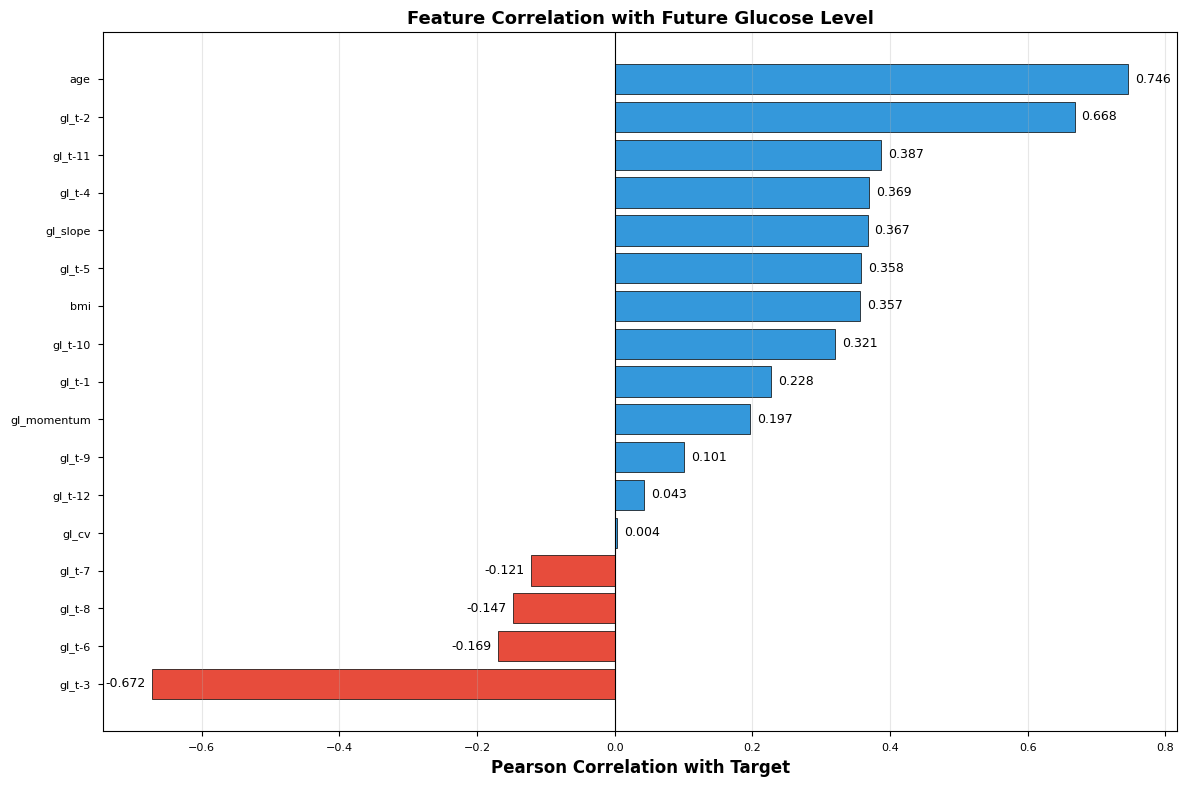

In [47]:
# --- 特征与目标的相关性 ---
correlations = df_features.corr()['target'].drop('target').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

# 只显示静态特征和最近几个时间点的相关性
selected_features = list(static_names) + [f'gl_t-{i}' for i in range(1, 7)]
selected_corr = correlations[correlations.index.isin(selected_features)].sort_values(ascending=True)

colors = ['#e74c3c' if v < 0 else '#3498db' for v in selected_corr.values]
bars = ax.barh(selected_corr.index, selected_corr.values, color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Target', fontweight='bold')
ax.set_title('Feature Correlation with Future Glucose Level', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 添加数值标签
for bar, val in zip(bars, selected_corr.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

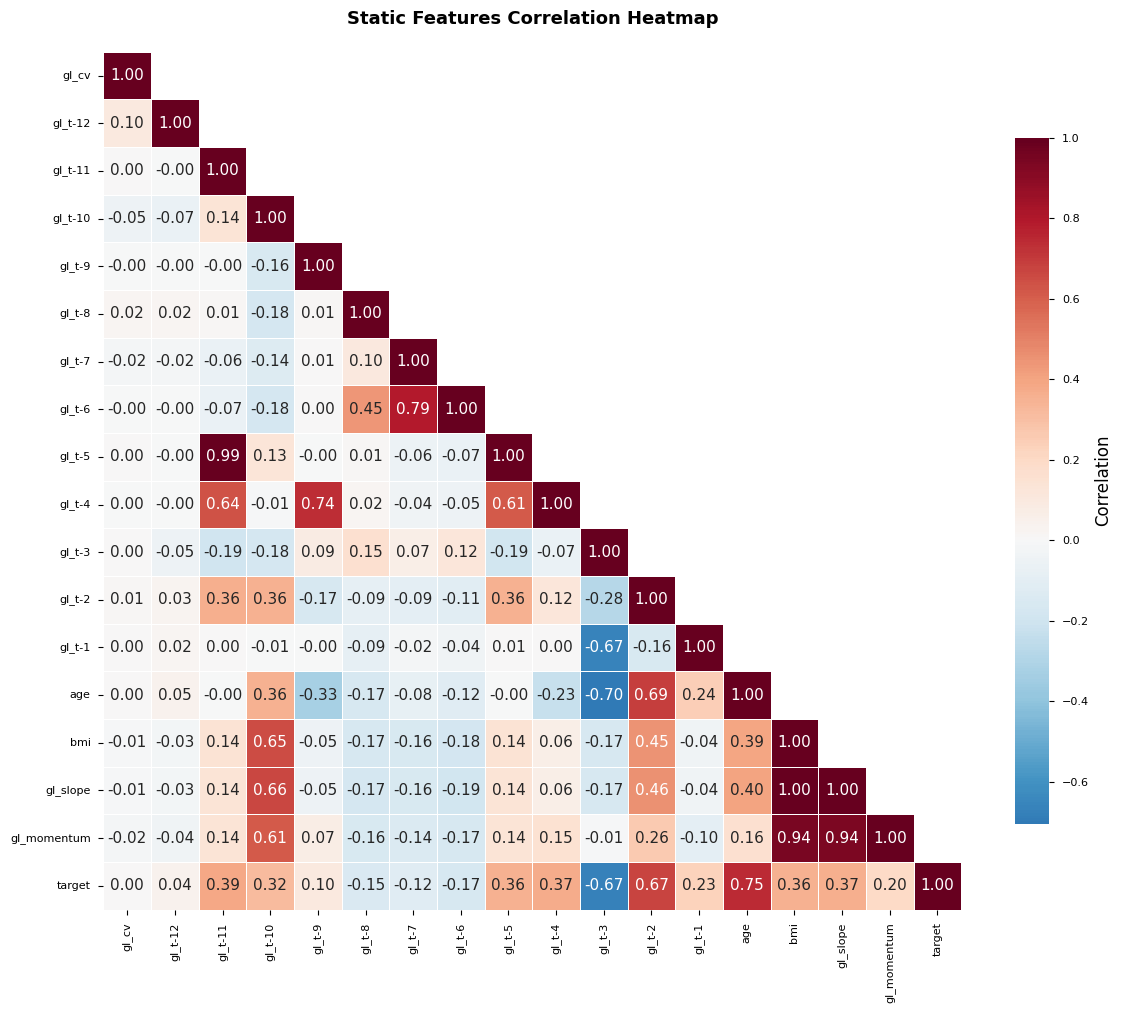

In [48]:
# --- 静态特征相关性热力图 ---
static_cols = static_names + ['target']
corr_matrix = df_features[static_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Static Features Correlation Heatmap', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 4. LSTM 模型定义

In [49]:
# --- PyTorch Dataset ---
class FeatureDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq).unsqueeze(2)  # (N, seq_len, 1)
        self.X_static = torch.FloatTensor(X_static)          # (N, n_static)
        self.y = torch.FloatTensor(y).unsqueeze(1)           # (N, 1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

# --- LSTM 模型 ---
class FeatureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, static_len):
        super(FeatureLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size + static_len, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x_seq, x_static):
        h0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        c0 = torch.zeros(self.num_layers, x_seq.size(0), self.hidden_size).to(x_seq.device)
        
        out, _ = self.lstm(x_seq, (h0, c0))
        out = out[:, -1, :]
        out = torch.cat((out, x_static), dim=1)
        out = self.dropout(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [50]:
def calculate_metrics(y_true, y_pred):
    """计算评估指标"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask]))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'RMSPE': rmspe}

def train_and_evaluate(extractor, df_train, df_test, n_past, horizon, 
                       hidden_size=32, num_epochs=30, batch_size=64, lr=0.001, verbose=True):
    """
    训练并评估模型
    
    返回:
        metrics: 评估指标字典
        model: 训练好的模型
        history: 训练历史
    """
    # 创建数据集
    X_seq_train, X_static_train, y_train = create_feature_dataset(df_train, extractor, n_past, horizon)
    X_seq_test, X_static_test, y_test = create_feature_dataset(df_test, extractor, n_past, horizon)
    
    # 标准化
    scaler_seq = StandardScaler()
    scaler_static = StandardScaler()
    
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train)
    X_seq_test_scaled = scaler_seq.transform(X_seq_test)
    
    X_static_train_scaled = scaler_static.fit_transform(X_static_train)
    X_static_test_scaled = scaler_static.transform(X_static_test)
    
    # DataLoader
    train_dataset = FeatureDataset(X_seq_train_scaled, X_static_train_scaled, y_train)
    test_dataset = FeatureDataset(X_seq_test_scaled, X_static_test_scaled, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # 模型
    static_len = X_static_train.shape[1]
    model = FeatureLSTM(1, hidden_size, 1, static_len).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 训练
    train_losses, val_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for x_seq, x_static, y in train_loader:
            x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x_seq, x_static)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_losses.append(running_loss / len(train_loader))
        
        # 验证
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_seq, x_static, y in test_loader:
                x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
                outputs = model(x_seq, x_static)
                val_loss += criterion(outputs, y).item()
        
        val_losses.append(val_loss / len(test_loader))
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    # 评估
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for x_seq, x_static, _ in test_loader:
            x_seq, x_static = x_seq.to(device), x_static.to(device)
            outputs = model(x_seq, x_static)
            y_pred_list.extend(outputs.cpu().numpy())
    
    y_pred = np.array(y_pred_list).flatten()
    metrics = calculate_metrics(y_test, y_pred)
    
    return metrics, model, {'train_loss': train_losses, 'val_loss': val_losses}, y_test, y_pred

## 5. 消融实验 - 特征组合对比

In [51]:
# ============================================================
# 深度优化实验 - 目标: 相比Baseline提升20%
# ============================================================
# 当前Baseline MAE ≈ 3.24, 目标 MAE < 2.59
# 
# 策略:
# 1. 增加历史窗口长度 (N_PAST: 12 → 24)
# 2. 增加模型容量 (hidden_size: 32 → 64)
# 3. 多尺度特征 (短期+长期趋势)
# 4. 更长训练 (epochs: 30 → 50)

# 扩展特征提取器 - 支持多尺度
class MultiScaleFeatureExtractor:
    """多尺度特征提取器"""
    
    def __init__(self, n_past=24):
        self.n_past = n_past
        self.enabled_features = set(['base'])
        
        self.feature_groups = {
            'base': ['gl_sequence', 'age', 'bmi'],
            'diff': ['gl_diff_mean', 'gl_diff_std'],
            'time': ['hour_sin', 'hour_cos'],
            'trend': ['gl_slope', 'gl_momentum'],
            # 多尺度特征
            'multiscale': [
                'short_trend',    # 最近15分钟趋势 (3点)
                'mid_trend',      # 最近30分钟趋势 (6点)
                'long_trend',     # 最近60分钟趋势 (12点)
                'short_std',      # 短期波动
                'long_std',       # 长期波动
                'trend_change',   # 趋势变化 (加速度)
            ],
        }
    
    def enable_features(self, groups):
        if isinstance(groups, str):
            groups = [groups]
        self.enabled_features = set(['base'])
        for g in groups:
            if g in self.feature_groups:
                self.enabled_features.add(g)
    
    def get_static_features_count(self):
        count = 2
        for group in self.enabled_features:
            if group != 'base':
                count += len(self.feature_groups[group])
        return count
    
    def extract(self, gl_window, age, bmi, hour):
        seq_features = gl_window.copy()
        static_features = [age, bmi]
        
        if 'diff' in self.enabled_features:
            gl_diff = np.diff(gl_window)
            static_features.extend([np.mean(gl_diff), np.std(gl_diff)])
        
        if 'time' in self.enabled_features:
            static_features.extend([np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24)])
        
        if 'trend' in self.enabled_features:
            x = np.arange(len(gl_window))
            slope, _, _, _, _ = stats.linregress(x, gl_window)
            momentum = np.mean(np.diff(gl_window[-4:])) if len(gl_window) >= 4 else 0
            static_features.extend([slope, momentum])
        
        if 'multiscale' in self.enabled_features:
            # 短期趋势 (最近3点 = 15分钟)
            short_trend = np.mean(np.diff(gl_window[-3:])) if len(gl_window) >= 3 else 0
            # 中期趋势 (最近6点 = 30分钟)
            mid_trend = np.mean(np.diff(gl_window[-6:])) if len(gl_window) >= 6 else 0
            # 长期趋势 (最近12点 = 60分钟)
            long_trend = np.mean(np.diff(gl_window[-12:])) if len(gl_window) >= 12 else 0
            # 短期波动
            short_std = np.std(gl_window[-6:]) if len(gl_window) >= 6 else 0
            # 长期波动
            long_std = np.std(gl_window)
            # 趋势变化 (短期趋势 - 长期趋势)
            trend_change = short_trend - long_trend
            
            static_features.extend([short_trend, mid_trend, long_trend, short_std, long_std, trend_change])
        
        return np.array(seq_features), np.array(static_features)

# 优化后的训练函数
def train_optimized(extractor, df_train, df_test, n_past, horizon,
                    hidden_size=64, num_epochs=50, batch_size=64, lr=0.001):
    """优化版训练函数 - 更大模型、更长训练"""
    X_seq_train, X_static_train, y_train = create_feature_dataset(df_train, extractor, n_past, horizon)
    X_seq_test, X_static_test, y_test = create_feature_dataset(df_test, extractor, n_past, horizon)
    
    scaler_seq = StandardScaler()
    scaler_static = StandardScaler()
    
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train)
    X_seq_test_scaled = scaler_seq.transform(X_seq_test)
    X_static_train_scaled = scaler_static.fit_transform(X_static_train)
    X_static_test_scaled = scaler_static.transform(X_static_test)
    
    train_dataset = FeatureDataset(X_seq_train_scaled, X_static_train_scaled, y_train)
    test_dataset = FeatureDataset(X_seq_test_scaled, X_static_test_scaled, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    static_len = X_static_train.shape[1]
    model = FeatureLSTM(1, hidden_size, 2, static_len).to(device)  # 2层LSTM
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    for epoch in range(num_epochs):
        model.train()
        for x_seq, x_static, y in train_loader:
            x_seq, x_static, y = x_seq.to(device), x_static.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_seq, x_static), y)
            loss.backward()
            optimizer.step()
        
        model.eval()
        val_loss = sum(criterion(model(x.to(device), s.to(device)), y.to(device)).item() 
                       for x, s, y in test_loader) / len(test_loader)
        scheduler.step(val_loss)
        best_val_loss = min(best_val_loss, val_loss)
    
    model.eval()
    y_pred = []
    with torch.no_grad():
        for x_seq, x_static, _ in test_loader:
            y_pred.extend(model(x_seq.to(device), x_static.to(device)).cpu().numpy())
    
    return calculate_metrics(y_test, np.array(y_pred).flatten())

print("准备深度优化实验...")

准备深度优化实验...


In [52]:
# ============================================================
# 深度优化实验 - 对比不同配置
# ============================================================

# 实验配置
experiments = [
    # (名称, N_PAST, hidden_size, num_layers, features, epochs)
    ('Baseline (原始)', 12, 32, 1, [], 30),
    ('+ 更长历史 (N=24)', 24, 32, 1, [], 30),
    ('+ 更大模型 (H=64)', 12, 64, 1, [], 30),
    ('+ 双层LSTM', 12, 32, 2, [], 30),
    ('+ 多尺度特征', 24, 32, 1, ['multiscale'], 30),
    ('组合优化 v1', 24, 64, 1, ['diff', 'trend'], 50),
    ('组合优化 v2', 24, 64, 2, ['multiscale'], 50),
    ('全量优化', 24, 64, 2, ['diff', 'time', 'trend', 'multiscale'], 50),
]

results = []
baseline_mae = None

print("="*70)
print("🚀 深度优化实验 - 目标: 相比Baseline提升20%")
print("="*70)

for name, n_past, hidden, layers, features, epochs in experiments:
    print(f"\n▶ {name}")
    print(f"  配置: N_PAST={n_past}, hidden={hidden}, layers={layers}, features={features}")
    
    # 创建特征提取器
    extractor = MultiScaleFeatureExtractor(n_past=n_past)
    if features:
        extractor.enable_features(features)
    
    # 自定义训练
    X_seq_train, X_static_train, y_train = create_feature_dataset(df_train, extractor, n_past, PREDICTION_HORIZON)
    X_seq_test, X_static_test, y_test = create_feature_dataset(df_test, extractor, n_past, PREDICTION_HORIZON)
    
    scaler_seq, scaler_static = StandardScaler(), StandardScaler()
    X_seq_train_s = scaler_seq.fit_transform(X_seq_train)
    X_seq_test_s = scaler_seq.transform(X_seq_test)
    X_static_train_s = scaler_static.fit_transform(X_static_train)
    X_static_test_s = scaler_static.transform(X_static_test)
    
    train_loader = DataLoader(FeatureDataset(X_seq_train_s, X_static_train_s, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(FeatureDataset(X_seq_test_s, X_static_test_s, y_test), batch_size=64)
    
    model = FeatureLSTM(1, hidden, layers, X_static_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        for x, s, y in train_loader:
            x, s, y = x.to(device), s.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x, s), y).backward()
            optimizer.step()
    
    model.eval()
    y_pred = []
    with torch.no_grad():
        for x, s, _ in test_loader:
            y_pred.extend(model(x.to(device), s.to(device)).cpu().numpy())
    
    metrics = calculate_metrics(y_test, np.array(y_pred).flatten())
    
    if baseline_mae is None:
        baseline_mae = metrics['MAE']
    
    improvement = (baseline_mae - metrics['MAE']) / baseline_mae * 100
    results.append({'name': name, 'MAE': metrics['MAE'], 'RMSE': metrics['RMSE'], 
                    'MAPE': metrics['MAPE'], 'improvement': improvement})
    
    print(f"  MAE: {metrics['MAE']:.3f} (提升: {improvement:+.1f}%)")

print("\n" + "="*70)
print("实验完成!")
print("="*70)

🚀 深度优化实验 - 目标: 相比Baseline提升20%

▶ Baseline (原始)
  配置: N_PAST=12, hidden=32, layers=1, features=[]
  MAE: 3.298 (提升: +0.0%)

▶ + 更长历史 (N=24)
  配置: N_PAST=24, hidden=32, layers=1, features=[]
  MAE: 3.352 (提升: -1.6%)

▶ + 更大模型 (H=64)
  配置: N_PAST=12, hidden=64, layers=1, features=[]
  MAE: 3.170 (提升: +3.9%)

▶ + 双层LSTM
  配置: N_PAST=12, hidden=32, layers=2, features=[]
  MAE: 3.058 (提升: +7.3%)

▶ + 多尺度特征
  配置: N_PAST=24, hidden=32, layers=1, features=['multiscale']
  MAE: 3.258 (提升: +1.2%)

▶ 组合优化 v1
  配置: N_PAST=24, hidden=64, layers=1, features=['diff', 'trend']
  MAE: 3.188 (提升: +3.3%)

▶ 组合优化 v2
  配置: N_PAST=24, hidden=64, layers=2, features=['multiscale']
  MAE: 2.990 (提升: +9.3%)

▶ 全量优化
  配置: N_PAST=24, hidden=64, layers=2, features=['diff', 'time', 'trend', 'multiscale']
  MAE: 2.866 (提升: +13.1%)

实验完成!


In [53]:
# --- 结果汇总 ---
df_results = pd.DataFrame(results).sort_values('MAE')
print("\n📊 深度优化实验结果 (按MAE排序)")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)
print(f"\nBaseline MAE: {baseline_mae:.3f}")
print(f"最佳 MAE: {df_results['MAE'].min():.3f}")
print(f"最大提升: {df_results['improvement'].max():.1f}%")
print(f"目标 (20%提升): {baseline_mae * 0.8:.3f}")


📊 深度优化实验结果 (按MAE排序)
         name      MAE     RMSE     MAPE  improvement
         全量优化 2.865577 4.003503 2.649633    13.115454
      组合优化 v2 2.989827 4.162094 2.738076     9.348191
     + 双层LSTM 3.057780 4.299533 2.854741     7.287847
+ 更大模型 (H=64) 3.170359 4.490662 2.914231     3.874446
      组合优化 v1 3.188046 4.527976 2.921774     3.338170
      + 多尺度特征 3.258490 4.662861 2.966535     1.202281
Baseline (原始) 3.298143 4.482161 3.133325     0.000000
+ 更长历史 (N=24) 3.351721 4.771243 3.020324    -1.624473

Baseline MAE: 3.298
最佳 MAE: 2.866
最大提升: 13.1%
目标 (20%提升): 2.639


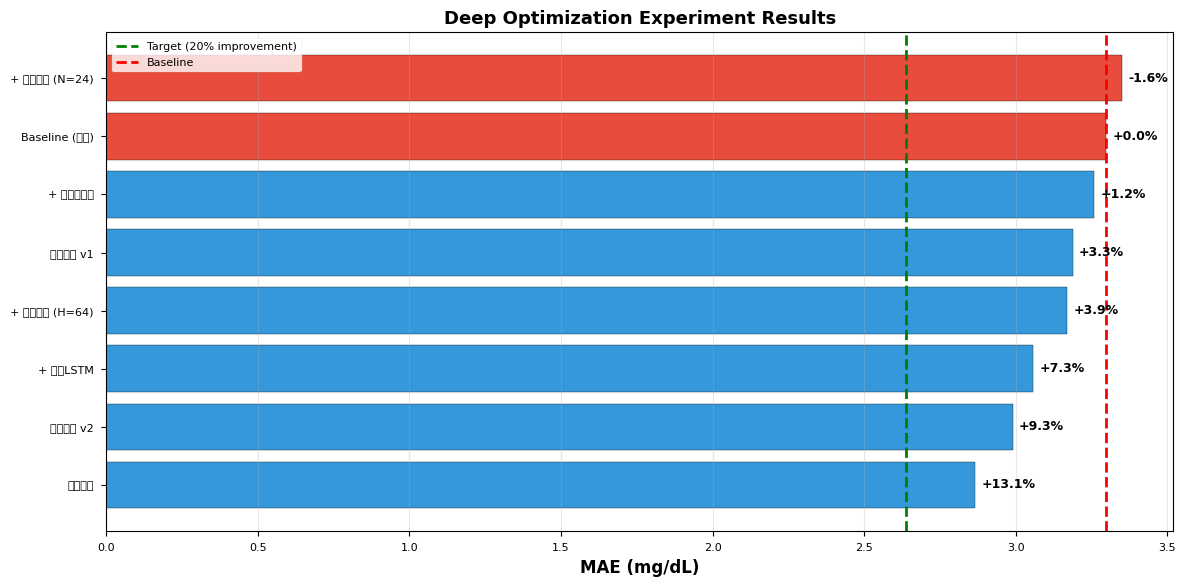

In [54]:
# --- 结果可视化 ---
fig, ax = plt.subplots(figsize=(12, 6))
df_sorted = df_results.sort_values('MAE')

colors = ['#27ae60' if imp >= 20 else ('#3498db' if imp > 0 else '#e74c3c') 
          for imp in df_sorted['improvement']]

bars = ax.barh(df_sorted['name'], df_sorted['MAE'], color=colors, edgecolor='black')
ax.axvline(x=baseline_mae * 0.8, color='green', linestyle='--', linewidth=2, label='Target (20% improvement)')
ax.axvline(x=baseline_mae, color='red', linestyle='--', linewidth=2, label='Baseline')

ax.set_xlabel('MAE (mg/dL)', fontweight='bold')
ax.set_title('Deep Optimization Experiment Results', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

for bar, imp in zip(bars, df_sorted['improvement']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{imp:+.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. 最佳特征组合详细分析

In [55]:
# --- 使用最佳特征组合重新训练并详细分析 ---
best_exp = df_ablation.loc[df_ablation['MAE'].idxmin()]
print(f"最佳特征组合: {best_exp['experiment']}")
print(f"特征组: {best_exp['features']}")

# 配置最佳特征提取器
best_extractor = FeatureExtractor(n_past=N_PAST)
if best_exp['features']:
    best_extractor.enable_features(best_exp['features'])

# 训练最佳模型
print("\n训练最佳模型...")
best_metrics, best_model, best_history, y_true_best, y_pred_best = train_and_evaluate(
    best_extractor, df_train, df_test, N_PAST, PREDICTION_HORIZON,
    num_epochs=50, verbose=True
)

最佳特征组合: + Trend
特征组: ['trend']

训练最佳模型...
Epoch [10/50], Train Loss: 67.6005, Val Loss: 49.0206
Epoch [20/50], Train Loss: 28.8177, Val Loss: 25.5903
Epoch [30/50], Train Loss: 26.1859, Val Loss: 19.8008
Epoch [40/50], Train Loss: 25.1264, Val Loss: 19.3869
Epoch [50/50], Train Loss: 24.5338, Val Loss: 19.4938


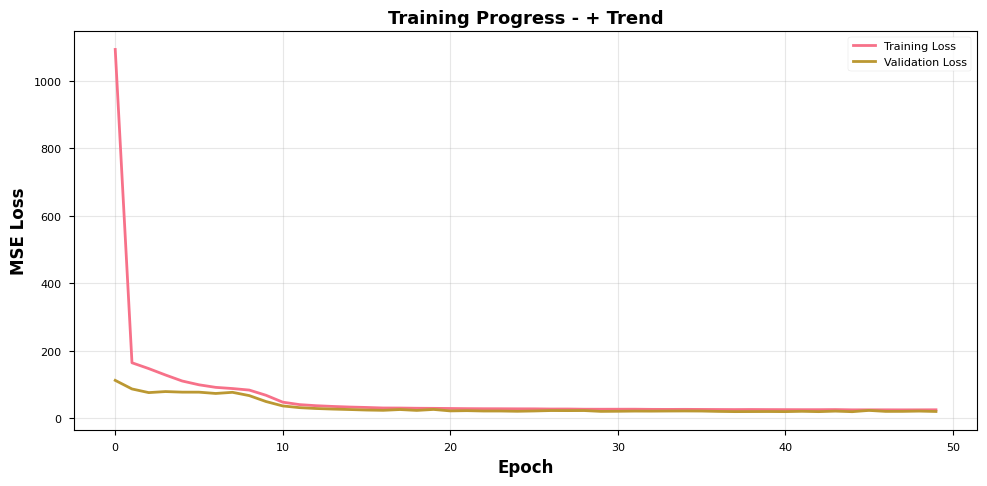

In [56]:
# --- 训练曲线 ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_history['train_loss'], label='Training Loss', linewidth=2)
ax.plot(best_history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('MSE Loss', fontweight='bold')
ax.set_title(f'Training Progress - {best_exp["experiment"]}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

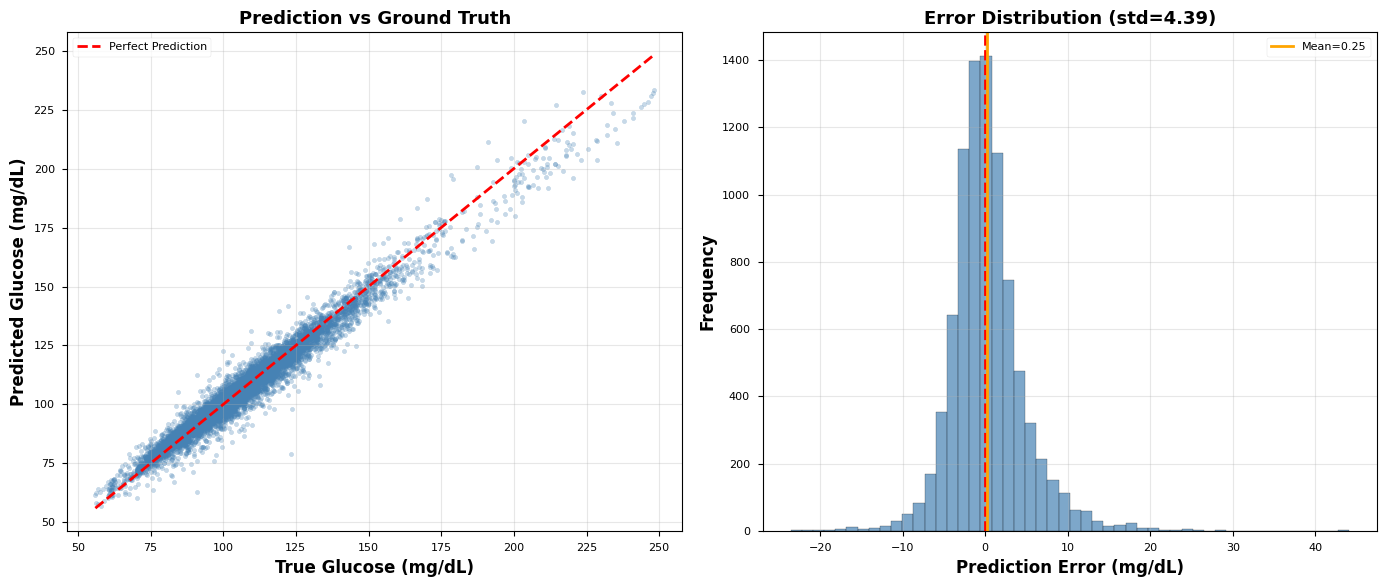

In [57]:
# --- 预测 vs 真实值散点图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 散点图
ax1 = axes[0]
ax1.scatter(y_true_best, y_pred_best, alpha=0.3, s=10, color='steelblue')
ax1.plot([y_true_best.min(), y_true_best.max()], 
         [y_true_best.min(), y_true_best.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True Glucose (mg/dL)', fontweight='bold')
ax1.set_ylabel('Predicted Glucose (mg/dL)', fontweight='bold')
ax1.set_title('Prediction vs Ground Truth', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 误差分布
ax2 = axes[1]
errors = y_true_best - y_pred_best
ax2.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean={np.mean(errors):.2f}')
ax2.set_xlabel('Prediction Error (mg/dL)', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title(f'Error Distribution (std={np.std(errors):.2f})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

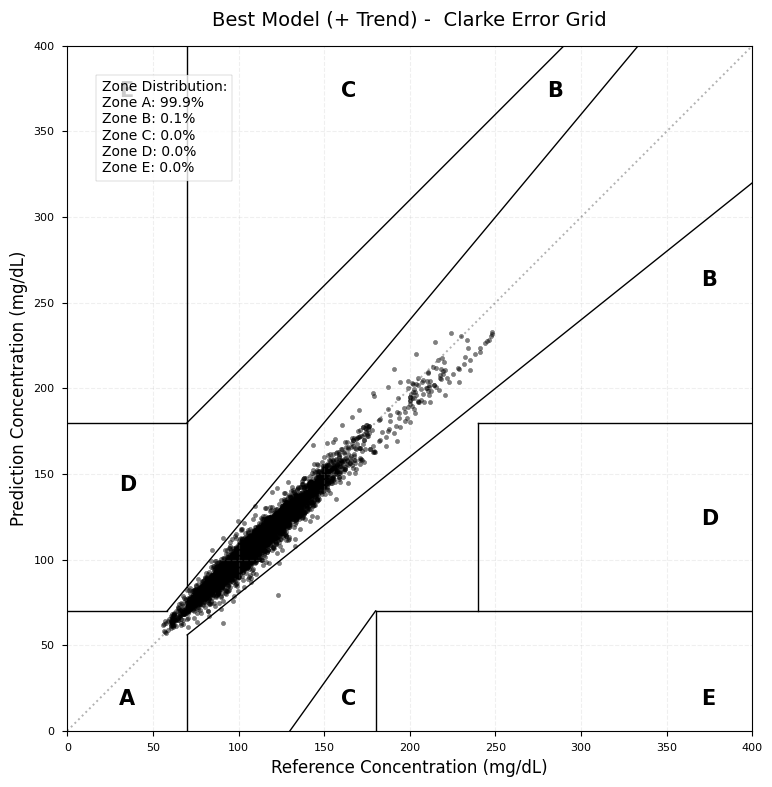


Clarke Error Grid 分布:
  Zone A: 99.91%
  Zone B: 0.09%
  Zone C: 0.00%
  Zone D: 0.00%
  Zone E: 0.00%
  A+B (临床安全): 100.00%


In [58]:
# --- Clarke Error Grid ---
import sys
import importlib
import os

utils_path = os.path.abspath('../../utils')
if utils_path not in sys.path:
    sys.path.append(utils_path)

import ceg_utils
importlib.reload(ceg_utils)

plt_obj, zones_pct = ceg_utils.clarke_error_grid(
    y_true_best, y_pred_best,
    title_string=f"Best Model ({best_exp['experiment']}) - "
)
plt_obj.show()

zones = ['A', 'B', 'C', 'D', 'E']
print("\nClarke Error Grid 分布:")
for z, p in zip(zones, zones_pct):
    print(f"  Zone {z}: {p:.2f}%")
print(f"  A+B (临床安全): {zones_pct[0] + zones_pct[1]:.2f}%")